# Experiment: Single-User Candidate Space Similarity

Objective:
- Compare two single-user scenarios: 300 Mbps at 200 m, and 100 Mbps at 400 m.
- Quantify how much their schedulable candidate spaces overlap after distance and rate constraints.
- Focus on throughput, required spectral efficiency, required SINR, and exact candidate overlap.
- Add a second, more scheduling-oriented similarity test by ignoring MCS and comparing shared radio envelopes.

Success criteria:
- Show whether the raw candidate catalog is identical across both users.
- Measure exact overlap after each user's constraints are applied.
- Measure resource-envelope overlap when the same radio shape survives but the preferred MCS may differ.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from downlink_candidate_evaluation.mcs_requirements import McsRequirementModel
from radio_core import SINGLE_USER_SEARCH_PRESET, build_model_inputs, build_single_user_deployment
from single_user_study import (
    build_single_user_scenario,
    enumerate_active_candidates,
    summarize_single_user_scenario,
)

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

ROOT


WindowsPath('C:/Users/henry/Documents/Masters Thesis/code')

## Plan

- Run the strict single-user search for both user requests.
- Enrich each candidate ledger with target-conditioned spectral-efficiency and SINR helpers.
- Compare similarity at three levels: raw catalog, exact feasible candidates, and shared radio envelopes that ignore MCS.
- Add a throughput-vs-SINR plane overlap metric as an additional proof of similarity.


In [2]:
SCENARIOS = [
    {
        'scenario': 'user_300mbps_200m',
        'label': '300 Mbps @ 200 m',
        'distance_m': 200.0,
        'required_rate_bps': 300e6,
    },
    {
        'scenario': 'user_100mbps_400m',
        'label': '100 Mbps @ 400 m',
        'distance_m': 400.0,
        'required_rate_bps': 100e6,
    },
]

CANDIDATE_ID_COLUMNS = [
    'pa_id',
    'bwp_idx',
    'n_prb',
    'n_slots_on',
    'layers',
    'n_active_tx',
    'mcs',
]
CORE_ID_COLUMNS = [
    'pa_id',
    'bwp_idx',
    'n_prb',
    'n_slots_on',
    'layers',
    'n_active_tx',
]

model_inputs = build_model_inputs(SINGLE_USER_SEARCH_PRESET)
link_constants = model_inputs['link_constants']
phy_constants = model_inputs['phy_constants']
mcs_table = model_inputs['mcs_table']

reference_deployment = build_single_user_deployment(
    link_constants,
    phy_constants,
    distance_m=SCENARIOS[0]['distance_m'],
)
mcs_requirement_model = McsRequirementModel(mcs_table)
mcs_requirements = (
    pd.DataFrame(mcs_requirement_model.current_required_sinr_table(reference_deployment))
    .assign(eta=lambda df: df['mcs'].map(lambda mcs: mcs_table[int(mcs)]['eta']))
    .sort_values('mcs')
    .reset_index(drop=True)
)
eta_grid = mcs_requirements['eta'].to_numpy()
mcs_grid = mcs_requirements['mcs'].to_numpy(dtype=int)
rho_req_db_grid = mcs_requirements['rho_req_db'].to_numpy()

N_RE_DATA_PER_PRB_PER_SLOT = 12.0 * (phy_constants['n_sym_data'] - phy_constants['n_dmrs_sym'])
T_WINDOW_S = phy_constants['n_slots_win'] * phy_constants['t_slot_s']


def lookup_min_supported_mcs(eta_required):
    eta_required = np.asarray(eta_required, dtype=float)
    idx = np.searchsorted(eta_grid, eta_required, side='left')
    out = np.full(eta_required.shape, np.nan)
    mask = idx < len(mcs_grid)
    out[mask] = mcs_grid[idx[mask]]
    return out


def lookup_required_sinr_db_for_eta(eta_required):
    mcs_required = lookup_min_supported_mcs(eta_required)
    out = np.full(mcs_required.shape, np.nan)
    mask = np.isfinite(mcs_required)
    out[mask] = rho_req_db_grid[mcs_required[mask].astype(int)]
    return out


def enrich_candidate_table(active_table, scenario):
    table = active_table.copy()
    required_rate_bps = float(scenario['required_rate_bps'])

    table['scenario'] = scenario['scenario']
    table['label'] = scenario['label']
    table['required_rate_bps'] = required_rate_bps
    table['required_rate_mbps'] = required_rate_bps / 1e6
    table['rate_ach_mbps'] = table['rate_ach_bps'] / 1e6
    table['occupied_bandwidth_hz'] = table['n_prb'] * 12.0 * phy_constants['delta_f_hz']
    table['occupied_bandwidth_mhz'] = table['occupied_bandwidth_hz'] / 1e6
    table['duty_cycle'] = table['n_slots_on'] / phy_constants['n_slots_win']
    table['resource_fraction'] = (table['occupied_bandwidth_hz'] / phy_constants['channel_bw_hz']) * table['duty_cycle']
    table['required_avg_spectral_efficiency_bphz'] = required_rate_bps / phy_constants['channel_bw_hz']

    denom = (
        table['n_slots_on'].to_numpy(dtype=float)
        * table['n_prb'].to_numpy(dtype=float)
        * N_RE_DATA_PER_PRB_PER_SLOT
        * table['layers'].to_numpy(dtype=float)
    )
    table['eta_req_for_target'] = np.where(
        denom > 0.0,
        required_rate_bps * T_WINDOW_S / denom,
        np.nan,
    )
    table['min_supported_mcs_for_target'] = lookup_min_supported_mcs(table['eta_req_for_target'].to_numpy())
    table['target_gamma_req_db'] = lookup_required_sinr_db_for_eta(table['eta_req_for_target'].to_numpy())

    table['gamma_req_db'] = np.nan
    gamma_req_mask = table['gamma_req_lin'] > 0.0
    table.loc[gamma_req_mask, 'gamma_req_db'] = 10.0 * np.log10(table.loc[gamma_req_mask, 'gamma_req_lin'])

    table['gamma_achieved_db'] = np.nan
    gamma_achieved_mask = table['gamma_achieved'] > 0.0
    table.loc[gamma_achieved_mask, 'gamma_achieved_db'] = 10.0 * np.log10(table.loc[gamma_achieved_mask, 'gamma_achieved'])

    table['feasible_for_user'] = table['rate_ach_bps'] >= required_rate_bps
    return table


def overlap_metrics(left, right, id_columns):
    left_unique = left[id_columns].drop_duplicates()
    right_unique = right[id_columns].drop_duplicates()
    intersection = left_unique.merge(right_unique, on=id_columns, how='inner')
    union_count = len(pd.concat([left_unique, right_unique], ignore_index=True).drop_duplicates())
    return {
        'left_count': len(left_unique),
        'right_count': len(right_unique),
        'intersection_count': len(intersection),
        'union_count': union_count,
        'jaccard_similarity': len(intersection) / union_count if union_count else np.nan,
        'left_coverage_by_shared': len(intersection) / len(left_unique) if len(left_unique) else np.nan,
        'right_coverage_by_shared': len(intersection) / len(right_unique) if len(right_unique) else np.nan,
    }


def throughput_sinr_plane_overlap(left, right, x_col='rate_ach_mbps', y_col='gamma_req_db', n_x_bins=16, n_y_bins=10):
    left = left[[x_col, y_col]].dropna()
    right = right[[x_col, y_col]].dropna()
    if left.empty or right.empty:
        return {
            'occupancy_jaccard': np.nan,
            'distribution_overlap': np.nan,
        }

    combined = pd.concat([left, right], ignore_index=True)
    x_edges = np.linspace(combined[x_col].min(), combined[x_col].max(), n_x_bins + 1)
    y_edges = np.linspace(combined[y_col].min(), combined[y_col].max(), n_y_bins + 1)

    hist_left, _, _ = np.histogram2d(left[x_col], left[y_col], bins=[x_edges, y_edges])
    hist_right, _, _ = np.histogram2d(right[x_col], right[y_col], bins=[x_edges, y_edges])

    occupancy_union = np.count_nonzero((hist_left > 0) | (hist_right > 0))
    occupancy_intersection = np.count_nonzero((hist_left > 0) & (hist_right > 0))

    left_mass = hist_left / hist_left.sum() if hist_left.sum() else hist_left
    right_mass = hist_right / hist_right.sum() if hist_right.sum() else hist_right

    return {
        'occupancy_jaccard': occupancy_intersection / occupancy_union if occupancy_union else np.nan,
        'distribution_overlap': np.minimum(left_mass, right_mass).sum(),
    }


mcs_requirements.head()


,mcs,rho_req_linear,rho_req_db,rho_req_mi_linear,rho_req_mi_db,eta
0,0,0.294,-5.318,0.147,-8.318,0.234
1,1,0.436,-3.605,0.219,-6.605,0.307
2,2,0.587,-2.315,0.294,-5.315,0.377
3,3,0.767,-1.152,0.384,-4.152,0.490
4,4,1.040,0.170,0.521,-2.830,0.602


In [3]:
scenario_tables = {}
scenario_summaries = []

for scenario in SCENARIOS:
    scenario_context = build_single_user_scenario(
        distance_m=scenario['distance_m'],
        required_rate_bps=scenario['required_rate_bps'],
    )
    scenario_views = summarize_single_user_scenario(scenario_context)
    active_table = enumerate_active_candidates(
        distance_m=scenario['distance_m'],
    )
    table = enrich_candidate_table(active_table, scenario)
    scenario_tables[scenario['scenario']] = table

    required_avg_se = table['required_avg_spectral_efficiency_bphz'].iloc[0]
    scenario_summaries.append(
        {
            'scenario': scenario['label'],
            'path_loss_db': table['path_loss_db'].dropna().iloc[0],
            'raw_candidate_count': int(scenario_views['search_space_summary']['raw_configs_per_scenario'].iloc[0]),
            'physically_feasible_count': int(len(table)),
            'target_feasible_count': int(table['feasible_for_user'].sum()),
            'required_avg_spectral_efficiency_bphz': required_avg_se,
            'best_case_target_sinr_db_for_full_band_use': lookup_required_sinr_db_for_eta(np.array([required_avg_se]))[0],
        }
    )

scenario_summary = pd.DataFrame(scenario_summaries)
scenario_summary


,scenario,path_loss_db,raw_candidate_count,physically_feasible_count,target_feasible_count,required_avg_spectral_efficiency_bphz,best_case_target_sinr_db_for_full_band_use
0,300 Mbps @ 200 m,119.229,779520,724060,11626,3.000,12.238
1,100 Mbps @ 400 m,129.845,779520,489720,22678,1.000,3.267


In [4]:
user_a = scenario_tables[SCENARIOS[0]['scenario']]
user_b = scenario_tables[SCENARIOS[1]['scenario']]

target_feasible_a = user_a[user_a['feasible_for_user']].copy()
target_feasible_b = user_b[user_b['feasible_for_user']].copy()

catalog_join = user_a.merge(user_b, on=CANDIDATE_ID_COLUMNS, suffixes=('_a', '_b'), validate='one_to_one')

catalog_invariance = pd.Series(
    {
        'raw_catalog_jaccard': overlap_metrics(user_a, user_b, CANDIDATE_ID_COLUMNS)['jaccard_similarity'],
        'matched_catalog_rows': len(catalog_join),
        'max_abs_rate_delta_bps': (catalog_join['rate_ach_bps_a'] - catalog_join['rate_ach_bps_b']).abs().max(),
        'max_abs_required_sinr_delta_db': (catalog_join['gamma_req_db_a'] - catalog_join['gamma_req_db_b']).abs().max(),
    },
    name='value',
)

overlap_summary = pd.DataFrame(
    {
        'raw_catalog': overlap_metrics(user_a, user_b, CANDIDATE_ID_COLUMNS),
        'target_feasible_exact_candidate': overlap_metrics(target_feasible_a, target_feasible_b, CANDIDATE_ID_COLUMNS),
        'target_feasible_resource_envelope': overlap_metrics(target_feasible_a, target_feasible_b, CORE_ID_COLUMNS),
    }
)

display(catalog_invariance.to_frame())
display(overlap_summary)


,value
raw_catalog_jaccard,0.676
matched_catalog_rows,"489,720.000"
max_abs_rate_delta_bps,0.000
max_abs_required_sinr_delta_db,0.000


,raw_catalog,target_feasible_exact_candidate,target_feasible_resource_envelope
left_count,"724,060.000","11,626.000","2,188.000"
right_count,"489,720.000","22,678.000","4,449.000"
intersection_count,"489,720.000",244.000,"1,953.000"
union_count,"724,060.000","34,060.000","4,684.000"
jaccard_similarity,0.676,0.007,0.417
left_coverage_by_shared,0.676,0.021,0.893
right_coverage_by_shared,1.000,0.011,0.439


In [5]:
shared_exact = target_feasible_a.merge(
    target_feasible_b,
    on=CANDIDATE_ID_COLUMNS,
    suffixes=('_a', '_b'),
)
plane_metrics = throughput_sinr_plane_overlap(target_feasible_a, target_feasible_b)

extra_similarity = pd.Series(
    {
        'throughput_sinr_occupancy_jaccard': plane_metrics['occupancy_jaccard'],
        'throughput_sinr_distribution_overlap': plane_metrics['distribution_overlap'],
        'shared_exact_candidate_count': len(shared_exact),
        'shared_candidate_dc_power_spearman': (
            shared_exact[['p_dc_avg_total_w_a', 'p_dc_avg_total_w_b']]
            .corr(method='spearman')
            .iloc[0, 1]
            if len(shared_exact) > 1
            else np.nan
        ),
        'median_extra_dc_power_for_400m_user_w': (
            (shared_exact['p_dc_avg_total_w_b'] - shared_exact['p_dc_avg_total_w_a']).median()
            if not shared_exact.empty
            else np.nan
        ),
    },
    name='value',
)

display(extra_similarity.to_frame())

shared_exact[
    [
        'pa_name_a',
        'bandwidth_hz_a',
        'n_prb',
        'n_slots_on',
        'layers',
        'n_active_tx',
        'mcs',
        'rate_ach_mbps_a',
        'gamma_req_db_a',
        'p_dc_avg_total_w_a',
        'p_dc_avg_total_w_b',
    ]
].sort_values(['p_dc_avg_total_w_b', 'gamma_req_db_a']).head(10)


,value
throughput_sinr_occupancy_jaccard,0.097
throughput_sinr_distribution_overlap,0.014
shared_exact_candidate_count,244.000
shared_candidate_dc_power_spearman,0.610
median_extra_dc_power_for_400m_user_w,42.347


,pa_name_a,bandwidth_hz_a,n_prb,n_slots_on,layers,n_active_tx,mcs,rate_ach_mbps_a,gamma_req_db_a,p_dc_avg_total_w_a,p_dc_avg_total_w_b
222,Bae et al. NR,"100,000,000.000",276,19,2,4,15,302.847,9.835,20.958,50.764
234,Bae et al. NR,"100,000,000.000",261,20,2,4,15,301.461,9.835,20.958,50.789
240,Bae et al. NR,"100,000,000.000",271,18,2,4,17,300.454,10.214,20.958,51.060
195,Bae et al. NR,"100,000,000.000",266,20,2,4,15,307.236,9.835,20.958,51.300
220,Bae et al. NR,"100,000,000.000",246,20,2,4,17,303.041,10.214,20.958,51.551
203,Bae et al. NR,"100,000,000.000",276,18,2,4,17,305.997,10.214,20.958,51.577
207,Bae et al. NR,"100,000,000.000",261,19,2,4,17,305.443,10.214,20.958,51.642
161,Bae et al. NR,"100,000,000.000",271,20,2,4,15,313.012,9.835,20.958,51.814
183,Bae et al. NR,"100,000,000.000",251,20,2,4,17,309.200,10.214,20.958,52.116
170,Bae et al. NR,"100,000,000.000",266,19,2,4,17,311.294,10.214,20.958,52.187


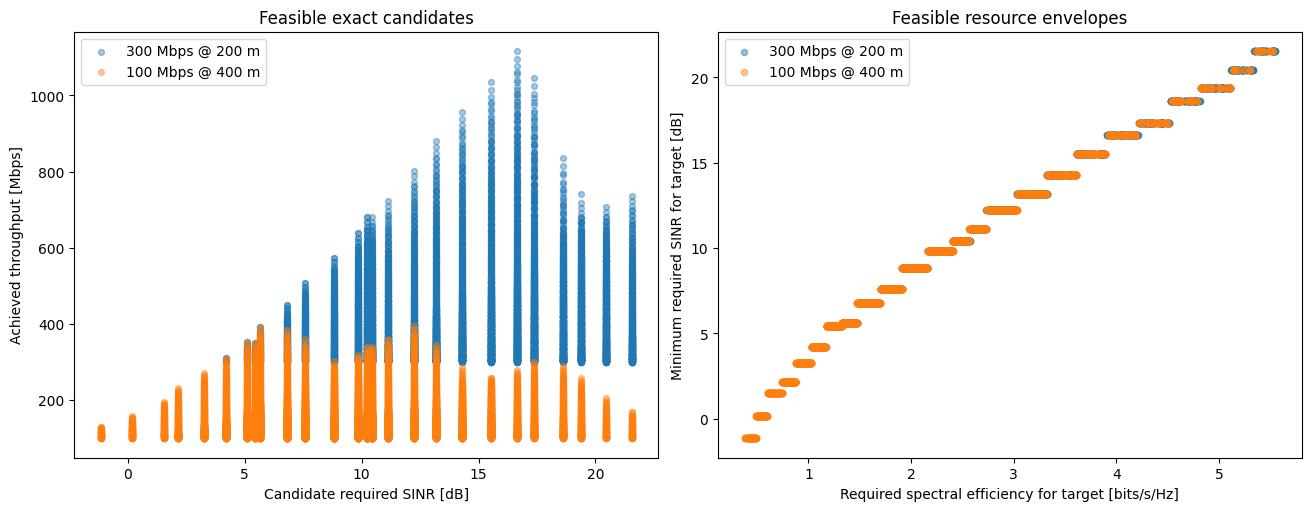

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

for scenario in SCENARIOS:
    table = scenario_tables[scenario['scenario']]
    feasible = table[table['feasible_for_user']]
    core_view = (
        feasible.sort_values(['target_gamma_req_db', 'eta_req_for_target'])
        .drop_duplicates(CORE_ID_COLUMNS)
    )

    axes[0].scatter(
        feasible['gamma_req_db'],
        feasible['rate_ach_mbps'],
        s=18,
        alpha=0.40,
        label=scenario['label'],
    )
    axes[1].scatter(
        core_view['eta_req_for_target'],
        core_view['target_gamma_req_db'],
        s=20,
        alpha=0.45,
        label=scenario['label'],
    )

axes[0].set_xlabel('Candidate required SINR [dB]')
axes[0].set_ylabel('Achieved throughput [Mbps]')
axes[0].set_title('Feasible exact candidates')
axes[0].legend()

axes[1].set_xlabel('Required spectral efficiency for target [bits/s/Hz]')
axes[1].set_ylabel('Minimum required SINR for target [dB]')
axes[1].set_title('Feasible resource envelopes')
axes[1].legend()

plt.show()


In [7]:
raw_jaccard = overlap_summary.loc['jaccard_similarity', 'raw_catalog']
exact_jaccard = overlap_summary.loc['jaccard_similarity', 'target_feasible_exact_candidate']
core_jaccard = overlap_summary.loc['jaccard_similarity', 'target_feasible_resource_envelope']
plane_overlap = extra_similarity.loc['throughput_sinr_distribution_overlap']
max_rate_delta = catalog_invariance.loc['max_abs_rate_delta_bps']
max_sinr_delta = catalog_invariance.loc['max_abs_required_sinr_delta_db']


def overlap_label(value):
    if not np.isfinite(value):
        return 'unknown'
    if value >= 0.67:
        return 'high'
    if value >= 0.33:
        return 'moderate'
    return 'low'


takeaways = pd.Series(
    [
        f'Raw catalog match: the two searches enumerate the same discrete candidate tuples (Jaccard = {raw_jaccard:.3f}).',
        f'Invariant parameters: matched candidates have max rate delta {max_rate_delta:.3f} bps and max required-SINR delta {max_sinr_delta:.3f} dB, so throughput and required SINR are effectively candidate properties, not user-distance properties.',
        f'After applying each user target, exact candidate overlap is {exact_jaccard:.3f} ({overlap_label(exact_jaccard)}), while resource-envelope overlap ignoring MCS is {core_jaccard:.3f} ({overlap_label(core_jaccard)}).',
        f'Throughput/SINR plane overlap is {plane_overlap:.3f}, which is a second similarity check that does not depend on exact tuple equality.',
        'Interpretation: if resource-envelope overlap stays materially larger than exact-candidate overlap, the two users are similar at the radio-scheduling level even when they prefer different MCS points on the same envelope.',
    ],
    name='takeaway',
)

takeaways.to_frame()


,takeaway
0,Raw catalog match: the two searches enumerate ...
1,Invariant parameters: matched candidates have ...
2,"After applying each user target, exact candida..."
3,"Throughput/SINR plane overlap is 0.014, which ..."
4,Interpretation: if resource-envelope overlap s...


## Next steps

- If the overlap looks promising, lift the same comparison into the TDMA scheduler and ask how many shared radio envelopes remain after coexistence constraints are added.
- If the overlap looks weak, break the rejection reasons apart and see whether path loss, PA caps, PSD caps, or the 300 Mbps rate cut removes the most shared candidates.
- A useful extension is to compare the best feasible MCS per shared envelope and measure how often the same envelope survives with only an MCS change.
